# <wc_2022.csv> Exploration:
- Downloaded from <https://www.kaggle.com/datasets/die9origephit/fifa-world-cup-2022-complete-dataset/data> on 6/24/26
- 64 x 88 table; each row is a game from the 2022 World Cup in Qatar
- The math on the game totals checks out. 32 teams; in the group stage, each plays 3 games, so 32 x 3 = 96; however, you have to divide that by 2 because each game features two teams, so that's 48 total games. In the knockout rounds, there are 15 elimination games (16 teams enter the knockout round, 15 are eliminated) + 1 consolation game for 3rd place. So: 48 + 15 + 1 = 64 total games.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
wc_2022 = pd.read_csv('wc_2022.csv')
wc_2022.head()

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42%,50%,8%,0,2,20 NOV 2022,17 : 00,Group A,...,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,...,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21 NOV 2022,17 : 00,Group A,...,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51%,39%,10%,1,1,21 NOV 2022,20 : 00,Group B,...,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22 NOV 2022,11 : 00,Group C,...,1,0,4,14,0,0,65,80,163,361


In [4]:
team_list = wc_2022['team1'].unique()

In [5]:
team_results_2022 = []
for team in team_list:
    games = 0
    goals_scored = 0
    goals_allowed = 0
    for i in range(wc_2022.shape[0]):
        if wc_2022.iloc[i, 0]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 5]
            goals_allowed += wc_2022.iloc[i, 6]
        elif wc_2022.iloc[i, 1]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 6]
            goals_allowed += wc_2022.iloc[i, 5]
    score_average = (goals_scored/games - goals_allowed/games)
    team_results_2022.append([team, games, goals_scored, goals_allowed, score_average])
team_results_2022

[['QATAR', 3, np.int64(1), np.int64(7), np.float64(-2.0)],
 ['ENGLAND', 5, np.int64(13), np.int64(4), np.float64(1.8)],
 ['SENEGAL', 4, np.int64(5), np.int64(7), np.float64(-0.5)],
 ['UNITED STATES', 4, np.int64(3), np.int64(4), np.float64(-0.25)],
 ['ARGENTINA', 7, np.int64(15), np.int64(8), np.float64(1.0)],
 ['DENMARK', 3, np.int64(1), np.int64(3), np.float64(-0.6666666666666667)],
 ['MEXICO', 3, np.int64(2), np.int64(3), np.float64(-0.33333333333333337)],
 ['FRANCE', 7, np.int64(16), np.int64(8), np.float64(1.1428571428571428)],
 ['MOROCCO', 7, np.int64(6), np.int64(5), np.float64(0.1428571428571428)],
 ['GERMANY', 3, np.int64(6), np.int64(5), np.float64(0.33333333333333326)],
 ['SPAIN', 4, np.int64(9), np.int64(3), np.float64(1.5)],
 ['BELGIUM', 3, np.int64(1), np.int64(2), np.float64(-0.3333333333333333)],
 ['SWITZERLAND', 4, np.int64(5), np.int64(9), np.float64(-1.0)],
 ['URUGUAY', 3, np.int64(2), np.int64(2), np.float64(0.0)],
 ['PORTUGAL', 5, np.int64(12), np.int64(6), np.floa

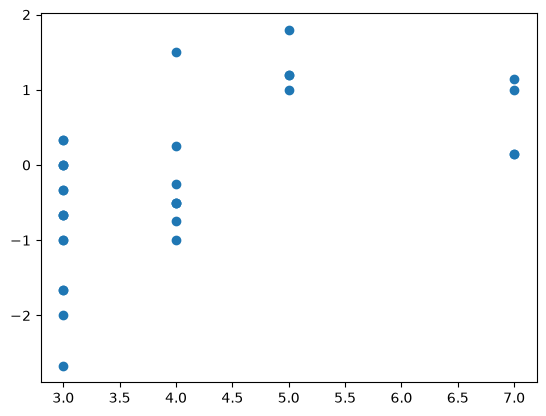

In [6]:
games_played = []
for i in range(len(team_results_2022)):
    games_played.append(team_results_2022[i][1])
score_average = []
for i in range(len(team_results_2022)):
    score_average.append(team_results_2022[i][4])
plt.scatter(games_played, score_average)